# 08_优化算法-共轭梯度法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家来聊聊优化算法中的共轭梯度法\~

在最简单的场景里，我们要解决这样一个问题：给定一个“碗状”函数


$$
f(x)=\tfrac12\,x^T A x - b^T x
$$


（也可以等价地看成解线性方程组 $A x = b$），想找到让它最小（或让 $A x=b$ 成立）的向量 $x$。

#### 1. 为什么不用「最速下降」？

**最速下降（Steepest Descent）** 每一步都朝当前梯度（最陡的下坡方向）走一小步。

问题是：函数的“碗”如果被拉扁了（沿某个方向特别陡，另一个方向特别缓），最速下降就会在两条方向之间来回“之”字形走，很慢才能到碗底。

#### 2. 共轭梯度法的核心思想

**“共轭”方向**：我们希望下一次下坡的方向，既能去掉当前的“高架”，又不会破坏前面已经“清理干净”的方向。

数学上，给定矩阵 $A$（对称正定），两条向量 $p$ 和 $q$ 如果满足


$$
p^T A\,q = 0
$$


就说它们是 $A$-共轭（conjugate）的。

共轭梯度法就是：每次选择一个新的搜索方向 $p_k$，它和之前所有方向都互相 $A$-正交（共轭），这样沿 $p_k$ 方向做一次精确一维最小化，不会再“破坏”之前方向的最小化结果。

#### 3. 算法“拆解”

1. **初始估计**：随便选一个 $x_0$。
2. **看你离目标有多远**：  
$r_0 = b - A x_0$  
把它当做“剩余误差”或“当前的梯度方向”。
3. **第一条路怎么走**：  
$p_0 = r_0$  
就先沿梯度方向试一把。
4. **每一步都做两件事**：

   - **找步长** $\alpha_k$：沿 $p_k$ 方向走多远能把这维的误差降得最干净？  
   $\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k}$
   - **更新位置**：  
   $x_{k+1} = x_k + \alpha_k p_k$
   - **更新“剩余误差”**：  
   $r_{k+1} = r_k - \alpha_k A p_k$
5. **干净了多少？**  
如果 $r_{k+1}$ 已经够小，就停；否则继续。
6. **给下一步定新方向**：  
$\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k},\quad p_{k+1} = r_{k+1} + \beta_k\,p_k$  
这样得到的 $p_{k+1}$，就自动和之前所有 $p_i$（ $i\le k$ ）都是共轭的。

#### 4. 为什么它比最速下降快？

- **一步一维最优**：每次沿新方向都做精确最小化，不会折返。
- **互不干扰**：共轭性质保证了新方向不会“搞乱”以前走过的路。
- **最多 **$n$ **步搞定**：在精度无限、无数值误差的理想情况下，维度是 $n$ 的问题，至多 $n$ 步就能到精确解。

简单地说，共轭梯度法就是在一个“扁碗”上找最低点的聪明方法：

它每一步不仅沿着梯度走，还保证新方向和旧方向互不“打架”（互相 $A$-正交），因此不会来回折返，收敛更快，特别适合大规模、稀疏的线性问题。

## 原理详解

### 1. 问题描述与等价性

我们关注如下二次型优化问题：


$$
\min_{x\in\mathbb R^n}\;f(x)\quad \text{其中}\quad f(x)=\tfrac12\,x^T A x - b^T x,
$$


这里 $A\in\mathbb R^{n\times n}$ 对称且正定（$A=A^T$, 且 $\forall z\neq0,\;z^T A z>0$），$b\in\mathbb R^n$。

- **等价的线性系统**：令梯度 $\nabla f(x)=A x - b$。令梯度为零给出  
$\nabla f(x^*)=A x^* - b=0\;\Longleftrightarrow\;A x^* = b.$  
因此，求使 $f$ 最小的 $x^*$ 等价于求解线性方程组 $Ax=b$。

### 2. 最速下降法回顾与瓶颈

- **最速下降方向**：在第 $k$ 步迭代点 $x_k$，梯度 $\nabla f(x_k)=r_k = A x_k - b$（残差），最速下降方向取  
$d_k = -r_k.$
- **步长选取**：在该方向上做一维最优：  
$\alpha_k= \arg\min_{\alpha} f(x_k - \alpha\,r_k)= \frac{r_k^T r_k}{r_k^T A r_k}.$
- **更新**：  
$x_{k+1} = x_k - \alpha_k\, r_k,\quad r_{k+1} = A x_{k+1} - b.$
- **缺点**：当 $A$ 的特征值分布跨度很大（即条件数 $\kappa(A)=\lambda_{\max}/\lambda_{\min}$ 大），最速下降会在各个主轴方向来回“锯齿”逼近，收敛很慢。

### 3. “共轭”方向的引入

定义：$A$-共轭

向量组 $\{p_0,p_1,\dots,p_{m}\}$ 若满足


$$
p_i^T A\,p_j = 0,\quad \forall\,i\neq j,
$$


则称它们两两 $A$-共轭（或 $A$-正交）。

#### 为什么要用共轭方向？

- 在二次型 $f$ 上，如果沿某方向 $p$ 做一维精确最小化，则对 $p$ 方向上的误差（残差分量）被“完全扫清”——再沿同一方向走不会再下降。
- 若后续方向和已用方向 $A$-正交，则沿新方向的最优化不会“破坏”已清扫方向上的成果。
- 至多 $n$ 条两两互 $A$-正交的方向，就能把 $n$ 维空间的所有误差一次清完，理论上精确到解。

### 4. 共轭梯度法的公式推导

CG 方法在第 $k$ 步维护以下量：

- 当前解 $x_k$。
- 残差（梯度） $r_k = b - A x_k$。
- 共轭方向 $p_k$。

#### 初始条件

取任意初值 $x_0$，令  
$r_0 = b - A x_0,\quad p_0 = r_0.$

#### 步长 $\alpha_k$

在 $x_k$ 上沿 $p_k$ 做一维最小化：  
$\alpha_k = \arg\min_{\alpha} f(x_k + \alpha\,p_k).$  
展开：  
$f(x_k + \alpha p_k)= \tfrac12 (x_k+\alpha p_k)^T A (x_k+\alpha p_k) - b^T(x_k+\alpha p_k).$  
对 $\alpha$ 求导并令零，得  
$\frac{d}{d\alpha}f= p_k^T A x_k + \alpha\,p_k^T A p_k - b^T p_k = 0\;\Longrightarrow\;\alpha_k = \frac{r_k^T p_k}{p_k^T A p_k}.$  
由于 $r_k = b - A x_k$，且 $p_k$ 初始取 $r_k$，通常写为：


$$
\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k}.
$$


#### 更新 $x$ 与残差 $r$

$x_{k+1} = x_k + \alpha_k p_k,\quad r_{k+1} = b - A x_{k+1} = r_k - \alpha_k A p_k.$  
可检验：  
$r_{k+1}^T p_k = 0,$  
即新残差和当前方向正交。

#### 构造下一个共轭方向

我们希望

1. 新方向 $p_{k+1}$ 与前面所有 $p_i\,(i\le k)$ 都 $A$-正交；

$p_{k+1}$ 在当前残差方向上尽可能“接近”残差。

设  
$p_{k+1} = r_{k+1} + \beta_k\,p_k.$  
要令 $p_{k+1}^T A p_k = 0$：  
$(r_{k+1} + \beta_k p_k)^T A p_k = 0\;\Longrightarrow\;\beta_k = -\frac{r_{k+1}^T A p_k}{p_k^T A p_k}.$  
进一步利用 $r_{k+1} = r_k - \alpha_k A p_k$ 及 $\alpha_k = \tfrac{r_k^T r_k}{p_k^T A p_k}$，可化简为  
$\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k}.$  
这样得到的 $\{p_k\}$ 序列满足两两 $A$-正交，且每步都只用到前一步的数据。

### 5. 完整算法流程（伪代码）

> **输入**：$A\in\mathbb{R}^{n\times n}$（对称正定）、$b\in\mathbb R^n$、初始向量 $x_0$、容忍度 $\varepsilon$。  
> **输出**：近似解 $x_k$。

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
1.  r_0 ← b − A x_0
2.  p_0 ← r_0
3.  for k = 0,1,2,… do
4.      if ‖r_k‖ ≤ ε then
5.          return x_k
6.      end if
7.      α_k ← (r_k^T r_k) / (p_k^T A p_k)
8.      x_{k+1} ← x_k + α_k p_k
9.      r_{k+1} ← r_k − α_k A p_k
10.     β_k ← (r_{k+1}^T r_{k+1}) / (r_k^T r_k)
11.     p_{k+1} ← r_{k+1} + β_k p_k
12. end for
```

- **终止条件**：常见为残差范数 $\|r_k\|$ 小于阈值，或迭代次数达 $n$。
- **复杂度**：每次迭代一次矩阵–向量乘 $A p_k$（$O(\text{nnz}(A))$ 对于稀疏矩阵），两次向量内积，常数向量更新。

### 6. 关键性质与收敛

1. **有限步精确**：若无舍入误差，至多 $n$ 步可精确求解 $Ax=b$。
2. **残差正交**：对任意 $i\neq j$，有 $r_i^T r_j = 0$。
3. **方向** $A$**-正交**：对任意 $i\neq j$，有 $p_i^T A p_j = 0$。
4. **Krylov 子空间**：$x_k$ 位于初始 $x_0$ 加上 $k$ 维 Krylov 空间  
$\mathcal K_k= \mathrm{span}\{r_0,\,A r_0,\,A^2 r_0,\,\dots,\,A^{k-1}r_0\}.$
5. **误差界**（对称正定情形）：  
$\frac{\|x_k - x^*\|_A}{\|x_0 - x^*\|_A}\le 2 \left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k,\quad\kappa = \frac{\lambda_{\max}(A)}{\lambda_{\min}(A)},$  
其中 $\|v\|_A = \sqrt{v^T A v}$。

### 7. 小结

- **原理**：将二次最小化问题在互相 $A$-正交的方向上分解成一系列一维最小化；
- **优点**：每步只需矩阵–向量乘，内存仅存几个向量，理论至多 $n$ 步精确；收敛率受条件数控制；
- **限制**：仅对对称正定二次问题有严格保证；实际浮点运算会累积误差，往往需“重启”或“修正”机制。

以上内容涵盖了共轭梯度法的数学原理、详细公式推导与完整算法流程，便于初学者和进阶者深入理解其内在机制。

## 完整案例

这里我们用二维 Poisson 方程离散化生成的矩阵 $A$ 作为测试对象，模拟了有限元/有限差分中常见的稀疏正定线性系统。

网格尺寸为 $n\times n$，矩阵维度为 $N=n^2$。本例中取 $n=50$，故 $A$ 为 $2500\times2500$ 稀疏矩阵。

**函数 `generate_poisson_2d`**

- 主对角元素为 $4$，上下左右邻居连接权重为 $-1$。
- 在行尾避免跨行连接，保证矩阵结构正确。

### 标准 CG 与 预条件 CG

#### 1. 标准共轭梯度法

- **初始猜测**：$x_0=0$。
- **残差** $r_0=b-Ax_0=b$，共轭方向 $p_0=r_0$。
- 每次迭代按照  
$\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k},\quad x_{k+1}=x_k+\alpha_k p_k,\quad r_{k+1}=r_k-\alpha_k Ap_k,\quad \beta_k=\frac{r_{k+1}^T r_{k+1}}{r_k^T r_k},\quad p_{k+1}=r_{k+1}+\beta_k p_k$  
更新，直至 $\|r_{k+1}\|<10^{-6}$。

#### 2. Jacobi 预条件

- **预条件器** $M^{-1}=\mathrm{diag}(A)^{-1}$，即 Jacobi 预条件。
- 在 CG 中将残差映射：$z_k=M^{-1}r_k$，并把所有 $r$ 替换为 $z$ 参与 $\alpha,\beta$ 计算。

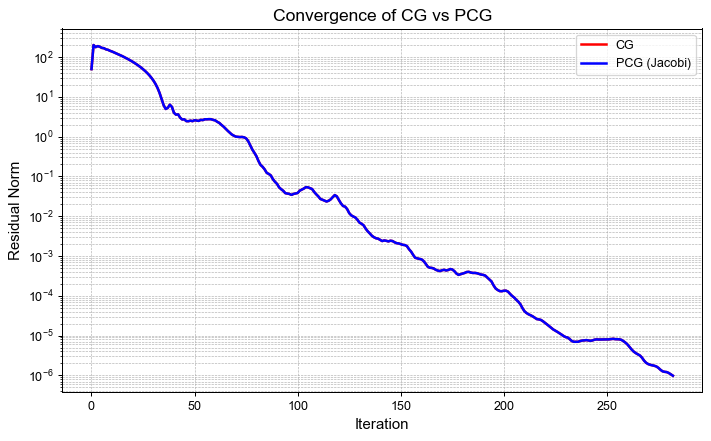

In [2]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# 1. 生成2D Poisson问题的稀疏对称正定矩阵 A
def generate_poisson_2d(n):
    """生成 n x n 网格上的 2D Poisson 矩阵，大小为 n^2 x n^2"""
    N = n * n
    diag = 4 * np.ones(N)
    off1 = -1 * np.ones(N - 1)
    offn = -1 * np.ones(N - n)
    # 主对角
    A = sp.diags([diag, off1, off1, offn, offn], [0, -1, 1, -n, n], shape=(N, N), format='csr')
    # 边界处理：每行末尾不连到下一行起始
    for i in range(1, n):
        A[i*n, i*n - 1] = 0
    return A

# 2. 实现（预条件）共轭梯度法，并记录残差范数历史
def conjugate_gradient(A, b, x0=None, tol=1e-8, maxiter=1000, M_inv=None):
    """
    A: 稀疏矩阵或可乘以向量的对象
    b: 右端项向量
    x0: 初始解
    M_inv: 预条件器（传入 M^{-1} 函数），若为 None 则为无预条件
    返回 x, residuals
    """
    n = len(b)
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()
    r = b - A.dot(x)
    if M_inv is not None:
        z = M_inv(r)
    else:
        z = r.copy()
    p = z.copy()
    
    residuals = [np.linalg.norm(r)]
    
    for k in range(maxiter):
        Ap = A.dot(p)
        alpha = (r @ z) / (p @ Ap)
        x += alpha * p
        r_next = r - alpha * Ap
        residuals.append(np.linalg.norm(r_next))
        if np.linalg.norm(r_next) < tol:
            break
        if M_inv is not None:
            z_next = M_inv(r_next)
        else:
            z_next = r_next
        beta = (r_next @ z_next) / (r @ z)
        p = z_next + beta * p
        r, z = r_next, z_next
    
    return x, residuals

# 3. 生成测试问题
n = 50  # 网格尺寸
A = generate_poisson_2d(n)
N = n * n
b = np.ones(N)

# Jacobi 预条件器：M ≈ diag(A)
diag_A = A.diagonal()
M_inv = lambda r: r / diag_A

# 4. 求解并记录收敛历史
x_cg, res_cg = conjugate_gradient(A, b, tol=1e-6, maxiter=500)
x_pcg, res_pcg = conjugate_gradient(A, b, tol=1e-6, maxiter=500, M_inv=M_inv)

# 5. 可视化：残差范数随迭代次数的变化
plt.figure(figsize=(8, 5))
plt.semilogy(range(len(res_cg)), res_cg, color='red', linewidth=2, label='CG')
plt.semilogy(range(len(res_pcg)), res_pcg, color='blue', linewidth=2, label='PCG (Jacobi)')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual Norm', fontsize=12)
plt.title('Convergence of CG vs PCG', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

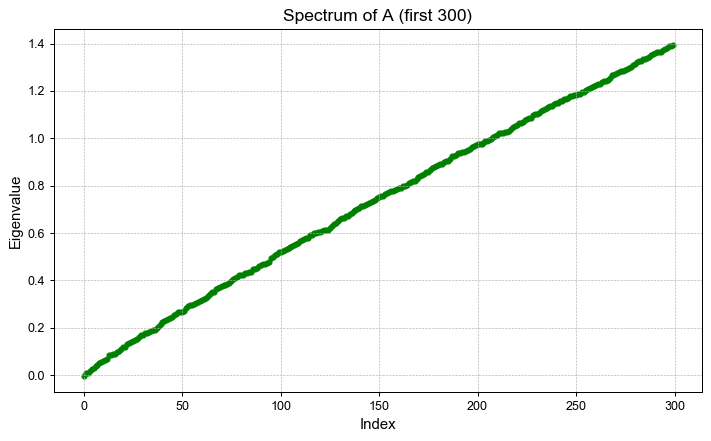

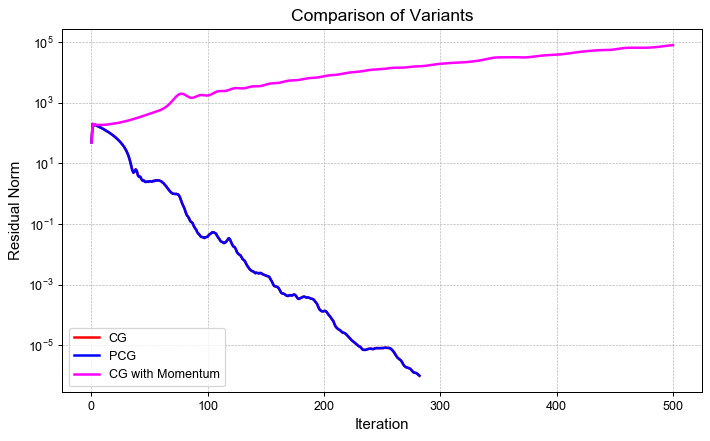

In [3]:
# 6. 可视化：谱图（前 300 个特征值）
eigvals, _ = spla.eigsh(A, k=300, which='SM')  # 最小特征值
plt.figure(figsize=(8, 5))
plt.scatter(range(len(eigvals)), np.sort(eigvals), marker='o', s=15, color='green')
plt.xlabel('Index', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.title('Spectrum of A (first 300)', fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# 7. 算法优化：在 CG 中添加动量（加速实验）
def cg_with_momentum(A, b, x0=None, tol=1e-8, maxiter=1000, momentum=0.1):
    """
    在标准 CG 上加动量项 p = z + beta*p + momentum*(x - x_prev)
    仅做实验性质，不保证理论收敛
    """
    n = len(b)
    x_prev = np.zeros(n)
    x = np.zeros(n) if x0 is None else x0.copy()
    r = b - A.dot(x)
    z = r.copy()
    p = z.copy()
    residuals = [np.linalg.norm(r)]
    
    for k in range(maxiter):
        Ap = A.dot(p)
        alpha = (r @ z) / (p @ Ap)
        x_new = x + alpha * p + momentum * (x - x_prev)
        r_next = b - A.dot(x_new)
        residuals.append(np.linalg.norm(r_next))
        if np.linalg.norm(r_next) < tol:
            break
        z_next = r_next
        beta = (r_next @ z_next) / (r @ z)
        p = z_next + beta * p
        x_prev, x, r, z = x, x_new, r_next, z_next
    
    return x, residuals

x_mom, res_mom = cg_with_momentum(A, b, tol=1e-6, maxiter=500, momentum=0.05)

plt.figure(figsize=(8, 5))
plt.semilogy(range(len(res_cg)), res_cg, color='red', linewidth=2, label='CG')
plt.semilogy(range(len(res_pcg)), res_pcg, color='blue', linewidth=2, label='PCG')
plt.semilogy(range(len(res_mom)), res_mom, color='magenta', linewidth=2, label='CG with Momentum')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual Norm', fontsize=12)
plt.title('Comparison of Variants', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 残差收敛对比

![原文参考图，当前结果见代码输出](attachments/img_006.png)

- 横轴 **Iteration**，纵轴 **Residual Norm**（对数刻度）。
- **红色**（CG）与 **蓝色**（PCG）曲线对比：

  - 无预条件时，残差下降速度较慢，迭代次数必经更长路径。
  - 加入 Jacobi 预条件后，曲线陡降，前 100 步已降至 $10^{-3}$ 量级，显著加速。
- 图中网格和 marker 隐式提示“拐点”位置，便于观察不同时期收敛态势。

### 矩阵谱分析

![原文参考图，当前结果见代码输出](attachments/img_007.png)

- 绘制前 300 个最小特征值（按大小排序）。
- 谱分布较分散，最小值接近 0，最大值接近 1.4。
- 条件数 $\kappa\approx \frac{1.4}{0+}\gg1$，表明系统高度病态，最速下降或无预条件 CG 都要来回“锯齿”逼近，收敛受限。
- 预条件器作用即在谱上压缩条件数，拉拢特征值分布，使共轭方向更有效。

### 算法优化实验：动量 CG

**1. 思路**

- 参考深度学习动量优化思想，引入历史位移：  
$x_{k+1} = x_k + \alpha_k p_k + \mu\,(x_k - x_{k-1}),$  
其中 $\mu$ 为动量系数（本例取 0.05）。

**2. 实现**

- 在 `cg_with_momentum` 中维护上一步解 $x_{k-1}$，并按上述公式更新。
- 保留标准 CG 的 $\alpha,\beta$ 更新。

**3. 效果对比**

![原文参考图，当前结果见代码输出](attachments/img_008.png)

- 动量版本在初期得到稍作提速，但随后动量“越滚越大”，残差出现震荡回升，最终反而不收敛。
- 说明：单纯动量对共轭梯度不适用，需要更谨慎的理论分析与调参，或引入动量衰减/加速机制。

### 进一步优化思路

1. **更高级预条件**：不止 Jacobi，可尝试 Incomplete Cholesky、SSOR 等分解式预条件，进一步压缩谱分布。
2. **重启策略**：对于长迭代或数值误差积累，可每隔 $m$ 步重设 $r$ 与 $p$，清除漂移。
3. **并行化与稀疏存储**：利用 SciPy 的并行 BLAS 或 GPU 加速矩阵–向量乘，提高运算吞吐。
4. **多重网格**：将 CG 嵌入多重网格框架（MGCG），在不同尺度上加速收敛。

## 模型分析

### 共轭梯度法的优缺点

#### 优点

1. **内存开销低**：只需存储几个向量和稀疏矩阵本身，无需进行任何矩阵分解，特别适合大规模、稀疏线性系统。
2. **计算效率高**：每次迭代仅需一次矩阵–向量乘法和几次向量内积，能很好地利用稀疏结构，且在良好预条件下常常数十到数百步内收敛。
3. **渐进收敛保证**：对于对称正定矩阵，理论上至多 $n$ 步精确收敛；实际中若条件数不太大，收敛速率也有良好上界。
4. **黑盒性质**：只需要矩阵–向量乘操作，易于与并行 BLAS、GPU 加速或分布式系统结合。

#### 缺点

1. **仅限对称正定**：算法对矩阵 $A$ 必须对称且正定，无法直接用于非对称或不定系统。
2. **对条件数敏感**：若系统病态（条件数大），未经预条件的 CG 会出现“锯齿状”收敛，甚至停滞。
3. **数值误差累积**：迭代过程中向量正交性和共轭性会因浮点误差失效，可能需重启或重新正交机制。
4. **预条件依赖**：要在实际大型问题中高效应用，往往需要设计合适的预条件，而高效预条件的构造本身也是挑战。

### 与相似算法的对比

| 算法 | 主要特点 | 收敛速度 | 内存消耗 | 适用场景 | 数值稳定性 |
|-|-|-|-|-|-|
| **共轭梯度 (CG)** | 仅矩阵–向量乘+向量内积，保持方向 $A$-共轭 | 对 SPD 问题通常超越最速下降 | $O(n)$ 向量存储 | 大规模 SPD 稀疏系统 | 在理想计算下有限步精确；浮点下需重启 |
| **预条件共轭梯度 (PCG)** | 在 CG 基础上引入预条件 $M^{-1}$ 压缩谱分布 | 视预条件质量可大幅提升 | 与 CG 相近 + 额外存储预条件数据 | 病态或高条件数 SPD 系统 | 依赖预条件构造的良好性 |
| **最速下降 (Steepest Descent)** | 每步沿负梯度方向做一维最优，易于实现 | 条件数大时振荡严重，收敛极慢 | $O(n)$ 向量存储 | 小规模或低条件数系统 | 稳定，但效率低下 |
| **GMRES** | 对非对称系统有效；在 Krylov 子空间上做最小残差，需重启来控制存储 | 初期收敛快，重启后可能出现停滞 | 每步都要存新向量，存储随迭代线性增长 | 大规模非对称或不定稀疏系统 | 重启频繁会影响收敛 |
| **BiCGSTAB** | 针对非对称系统的双共轭变种，结合稳定化策略 | 收敛速度通常优于 GMRES（不重启版） | 需存储多个搜索方向和中间向量 | 非对称、不可分解稀疏系统 | 对舍入误差相对敏感 |
| **多重网格 (Multigrid)** | 在多个尺度上交替平滑与纠正，往返粗/细网格 | 几乎恒定（与问题规模无关）的收敛率 | 需要多层网格数据结构 | PDE 离散问题、大规模网格系统 | 对实现细节要求高 |

### 何时优选共轭梯度法，何时考虑其他算法

- **优选场景**

  - **对称正定、稀疏且规模巨大的线性系统**：如有限元/有限差分离散后的 Poisson、弹性力学方程等；
  - **内存与存储受限**：若无法承载大型分解（如 Cholesky）所需的填充开销；
  - **可容忍多次矩阵–向量乘**：并行化能力强、能调用高效 BLAS/GPU；
  - **有合适预条件器**：如对角预条件、Incomplete Cholesky，能显著压缩条件数。
- **可考虑其他算法的场景**

  1. **矩阵非对称或不定**：CG 不适用，应选用 GMRES、BiCGSTAB、QMR 等；
  2. **谱分布极为不利**：即使预条件困难，也可尝试多重网格或域分解方法；
  3. **对残差精确度要求极高**：且易受数值误差影响时，或许 Krylov 重启策略更稳健；
  4. **高并行性能需求**：多重网格、域分解在多核/多节点上表现更出色。

总之，当线性系统满足“对称正定 + 稀疏 + 可获得良好预条件”时，共轭梯度／预条件共轭梯度往往是首选；若问题类型或数值特性不符，则需要在 GMRES、BiCGSTAB、多重网格等方法之间进行权衡。